In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[0]
sys.path.append(str(PROJECT_ROOT))

In [2]:
import pandas as pd
df = pd.read_csv("../data/vanilla_convertibles_data_enhanced.csv")

In [3]:
from sklearn.model_selection import train_test_split

df = df.dropna(subset=["price_normalized"])

X = df.drop(columns=["price_convertible", "price_normalized", "redemption"])
y = df[["price_normalized"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.20, random_state=42)


In [4]:
import numpy as np
from sklearn.preprocessing import QuantileTransformer
from sklearn.preprocessing._data import BOUNDS_THRESHOLD
from scipy.stats import norm

scaler_X = QuantileTransformer(output_distribution="normal", random_state=42)
scaler_y = QuantileTransformer(output_distribution="normal", random_state=42)

X_train = scaler_X.fit_transform(X_train)
X_val = scaler_X.transform(X_val)
X_test = scaler_X.transform(X_test)

y_train = scaler_y.fit_transform(y_train)
y_val = scaler_y.transform(y_val)

# Replace ±inf with sklearn's natural boundary: ppf at BOUNDS_THRESHOLD ≈ ±5.1993
_lower = norm.ppf(BOUNDS_THRESHOLD)
_upper = norm.ppf(1 - BOUNDS_THRESHOLD)
X_train = np.clip(X_train, _lower, _upper)
X_val = np.clip(X_val, _lower, _upper)
X_test = np.clip(X_test, _lower, _upper)
y_train = np.clip(y_train, _lower, _upper)
y_val = np.clip(y_val, _lower, _upper)

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim

In [6]:
INPUT_DIM = X_train.shape[1]
OUTPUT_DIM = y_train.shape[1]

WIDTH = 528
DEPTHS = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

BATCH_SIZE = 1024
LR = 1e-3
EPOCHS = 200
PATIENCE = 10

SEED = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device} | Input: {INPUT_DIM} | Output: {OUTPUT_DIM}")

Device: cpu | Input: 24 | Output: 1


In [7]:
from torch.utils.data import TensorDataset, DataLoader

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=BATCH_SIZE)

In [8]:
from architectures.nn_build import build_mlp

results = []

for depth in DEPTHS:
    print(f"\n{'='*40}")
    print(f"Depth={depth}, Width={WIDTH}")
    print(f"{'='*40}")

    torch.manual_seed(SEED)
    model = build_mlp(INPUT_DIM, OUTPUT_DIM, depth, WIDTH, batch_norm=True).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
    criterion = nn.MSELoss()

    best_val = float("inf")
    best_state = None
    wait = 0

    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = criterion(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item() * len(xb)
        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                val_loss += criterion(model(xb), yb).item() * len(xb)
        val_loss /= len(val_loader.dataset)

        if val_loss < best_val:
            best_val = val_loss
            best_state = model.state_dict().copy()
            wait = 0
        else:
            wait += 1

        if (epoch + 1) % 10 == 0 or wait == 0:
            print(f"  Epoch {epoch+1:3d} | Train: {train_loss:.6f} | Val: {val_loss:.6f} | Wait: {wait}")

        if wait >= PATIENCE:
            print(f"  Early stop at epoch {epoch+1}")
            break

    results.append({"depth": depth, "best_val_loss": best_val, "best_state": best_state})
    print(f"  Best Val Loss: {best_val:.6f}")


Depth=1, Width=528
  Epoch   1 | Train: 0.053431 | Val: 0.021229 | Wait: 0
  Epoch   2 | Train: 0.015057 | Val: 0.008888 | Wait: 0
  Epoch   3 | Train: 0.011712 | Val: 0.007289 | Wait: 0
  Epoch   4 | Train: 0.010071 | Val: 0.005957 | Wait: 0
  Epoch   5 | Train: 0.009312 | Val: 0.005197 | Wait: 0
  Epoch   6 | Train: 0.008046 | Val: 0.004380 | Wait: 0
  Epoch   7 | Train: 0.007933 | Val: 0.003960 | Wait: 0
  Epoch  10 | Train: 0.006823 | Val: 0.003523 | Wait: 0
  Epoch  12 | Train: 0.006361 | Val: 0.002590 | Wait: 0
  Epoch  18 | Train: 0.004878 | Val: 0.002315 | Wait: 0
  Epoch  20 | Train: 0.005052 | Val: 0.005553 | Wait: 2
  Epoch  22 | Train: 0.004755 | Val: 0.001923 | Wait: 0
  Epoch  23 | Train: 0.004421 | Val: 0.001718 | Wait: 0
  Epoch  29 | Train: 0.004563 | Val: 0.001382 | Wait: 0
  Epoch  30 | Train: 0.004192 | Val: 0.002990 | Wait: 1
  Epoch  35 | Train: 0.003962 | Val: 0.001357 | Wait: 0
  Epoch  37 | Train: 0.003773 | Val: 0.001210 | Wait: 0
  Epoch  39 | Train: 0.00364

In [9]:
summary = pd.DataFrame([(r["depth"], r["best_val_loss"]) for r in results],
                        columns=["depth", "best_val_loss"])
print(summary.to_string(index=False))

best = summary.loc[summary["best_val_loss"].idxmin()]
print(f"\nBest depth: {int(best['depth'])} with val loss: {best['best_val_loss']:.6f}")

 depth  best_val_loss
     1       0.001152
     2       0.000724
     3       0.000407
     4       0.000602
     5       0.000298
     6       0.000342
     7       0.000255
     8       0.000464
     9       0.000530
    10       0.000284

Best depth: 7 with val loss: 0.000255


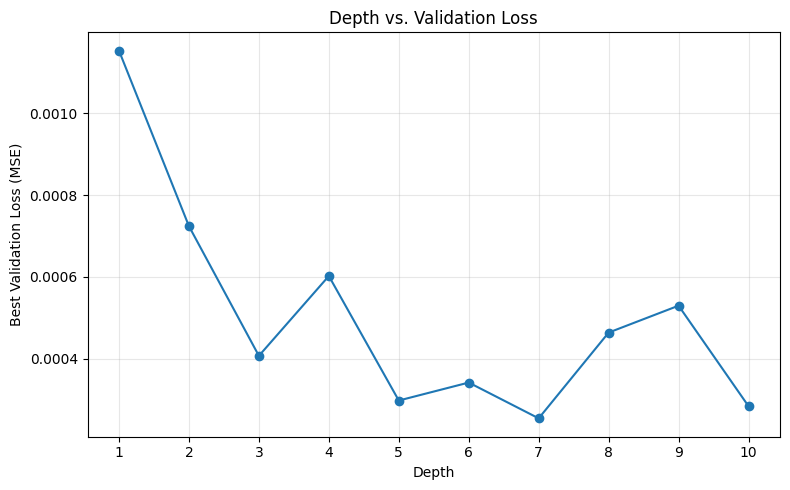

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(summary["depth"], summary["best_val_loss"], marker="o")
plt.xlabel("Depth")
plt.ylabel("Best Validation Loss (MSE)")
plt.title("Depth vs. Validation Loss")
plt.xticks(summary["depth"].astype(int))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
DEPTH = 7

WIDTHS = [32, 64, 128, 256, 512, 1024, 2048, 2560, 3072]

In [12]:
results = []

for width in WIDTHS:
    print(f"\n{'='*40}")
    print(f"Depth={DEPTH}, Width={width}")
    print(f"{'='*40}")

    torch.manual_seed(SEED)
    model = build_mlp(INPUT_DIM, OUTPUT_DIM, DEPTH, width, batch_norm=True).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
    criterion = nn.MSELoss()

    best_val = float("inf")
    best_state = None
    wait = 0

    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = criterion(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item() * len(xb)
        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                val_loss += criterion(model(xb), yb).item() * len(xb)
        val_loss /= len(val_loader.dataset)

        if val_loss < best_val:
            best_val = val_loss
            best_state = model.state_dict().copy()
            wait = 0
        else:
            wait += 1

        if (epoch + 1) % 10 == 0 or wait == 0:
            print(f"  Epoch {epoch+1:3d} | Train: {train_loss:.6f} | Val: {val_loss:.6f} | Wait: {wait}")

        if wait >= PATIENCE:
            print(f"  Early stop at epoch {epoch+1}")
            break

    results.append({"width": width, "best_val_loss": best_val, "best_state": best_state})
    print(f"  Best Val Loss: {best_val:.6f}")


Depth=7, Width=32
  Epoch   1 | Train: 0.072386 | Val: 0.008049 | Wait: 0
  Epoch   2 | Train: 0.009744 | Val: 0.004581 | Wait: 0
  Epoch   3 | Train: 0.007206 | Val: 0.003511 | Wait: 0
  Epoch   4 | Train: 0.006248 | Val: 0.002792 | Wait: 0
  Epoch   5 | Train: 0.005773 | Val: 0.002403 | Wait: 0
  Epoch   7 | Train: 0.004952 | Val: 0.002115 | Wait: 0
  Epoch   8 | Train: 0.004722 | Val: 0.001793 | Wait: 0
  Epoch   9 | Train: 0.004629 | Val: 0.001777 | Wait: 0
  Epoch  10 | Train: 0.004624 | Val: 0.001710 | Wait: 0
  Epoch  11 | Train: 0.004461 | Val: 0.001178 | Wait: 0
  Epoch  20 | Train: 0.003535 | Val: 0.001059 | Wait: 0
  Epoch  21 | Train: 0.003931 | Val: 0.001055 | Wait: 0
  Epoch  23 | Train: 0.003618 | Val: 0.001036 | Wait: 0
  Epoch  24 | Train: 0.003588 | Val: 0.000896 | Wait: 0
  Epoch  27 | Train: 0.003414 | Val: 0.000776 | Wait: 0
  Epoch  30 | Train: 0.003264 | Val: 0.000996 | Wait: 3
  Epoch  32 | Train: 0.003558 | Val: 0.000711 | Wait: 0
  Epoch  35 | Train: 0.003374

In [13]:
width_summary = pd.DataFrame([(r["width"], r["best_val_loss"]) for r in results],
                              columns=["width", "best_val_loss"])
print(width_summary.to_string(index=False))

best_w = width_summary.loc[width_summary["best_val_loss"].idxmin()]
print(f"\nBest width: {int(best_w['width'])} with val loss: {best_w['best_val_loss']:.6f}")

 width  best_val_loss
    32       0.000521
    64       0.000404
   128       0.000488
   256       0.000439
   512       0.000301
  1024       0.000618
  2048       0.001549
  2560       0.000707
  3072       0.000434

Best width: 512 with val loss: 0.000301


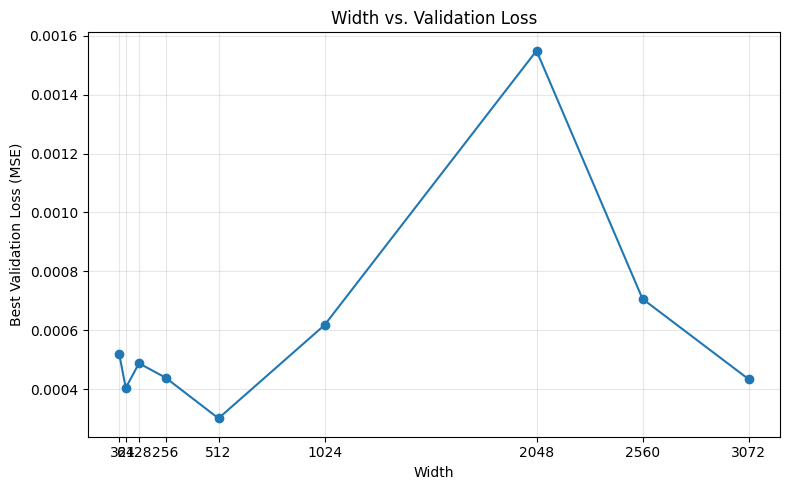

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(width_summary["width"], width_summary["best_val_loss"], marker="o")
plt.xlabel("Width")
plt.ylabel("Best Validation Loss (MSE)")
plt.title("Width vs. Validation Loss")
plt.xticks(width_summary["width"].astype(int))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
GRID_DEPTHS = [5, 6, 7, 8, 9, 10]
GRID_WIDTHS = [384, 512, 1024, 1536, 3072]

print(f"Grid search: {len(GRID_DEPTHS)} depths x {len(GRID_WIDTHS)} widths = {len(GRID_DEPTHS)*len(GRID_WIDTHS)} combinations")

Grid search: 6 depths x 5 widths = 30 combinations


In [18]:
grid_results = []

for depth in GRID_DEPTHS:
    for width in GRID_WIDTHS:
        print(f"\n{'='*40}")
        print(f"Depth={depth}, Width={width}")
        print(f"{'='*40}")

        torch.manual_seed(SEED)
        model = build_mlp(INPUT_DIM, OUTPUT_DIM, depth, width, batch_norm=True).to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
        criterion = nn.MSELoss()

        best_val = float("inf")
        best_state = None
        wait = 0

        for epoch in range(EPOCHS):
            model.train()
            train_loss = 0.0
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                loss = criterion(pred, yb)
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                train_loss += loss.item() * len(xb)
            train_loss /= len(train_loader.dataset)

            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for xb, yb in val_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    val_loss += criterion(model(xb), yb).item() * len(xb)
            val_loss /= len(val_loader.dataset)

            if val_loss < best_val:
                best_val = val_loss
                best_state = model.state_dict().copy()
                wait = 0
            else:
                wait += 1

            if (epoch + 1) % 10 == 0 or wait == 0:
                print(f"  Epoch {epoch+1:3d} | Train: {train_loss:.6f} | Val: {val_loss:.6f} | Wait: {wait}")

            if wait >= PATIENCE:
                print(f"  Early stop at epoch {epoch+1}")
                break

        grid_results.append({"depth": depth, "width": width, "best_val_loss": best_val, "best_state": best_state})
        print(f"  Best Val Loss: {best_val:.6f}")


Depth=5, Width=384
  Epoch   1 | Train: 0.021930 | Val: 0.008423 | Wait: 0
  Epoch   2 | Train: 0.008402 | Val: 0.006130 | Wait: 0
  Epoch   4 | Train: 0.006320 | Val: 0.001343 | Wait: 0
  Epoch   8 | Train: 0.004471 | Val: 0.000829 | Wait: 0
  Epoch  10 | Train: 0.004106 | Val: 0.001837 | Wait: 2
  Early stop at epoch 18
  Best Val Loss: 0.000829

Depth=5, Width=512
  Epoch   1 | Train: 0.032682 | Val: 0.007815 | Wait: 0
  Epoch   2 | Train: 0.010137 | Val: 0.004649 | Wait: 0
  Epoch   4 | Train: 0.007676 | Val: 0.004038 | Wait: 0
  Epoch   7 | Train: 0.005463 | Val: 0.002596 | Wait: 0
  Epoch   8 | Train: 0.004982 | Val: 0.002083 | Wait: 0
  Epoch  10 | Train: 0.004329 | Val: 0.001080 | Wait: 0
  Epoch  11 | Train: 0.004742 | Val: 0.000917 | Wait: 0
  Epoch  15 | Train: 0.003426 | Val: 0.000773 | Wait: 0
  Epoch  16 | Train: 0.003365 | Val: 0.000642 | Wait: 0
  Epoch  20 | Train: 0.003108 | Val: 0.001383 | Wait: 4
  Epoch  22 | Train: 0.002791 | Val: 0.000461 | Wait: 0
  Epoch  29 |

In [21]:
grid_df = pd.DataFrame([(r["depth"], r["width"], r["best_val_loss"]) for r in grid_results],
                       columns=["depth", "width", "best_val_loss"])
print(grid_df.sort_values("best_val_loss").to_string(index=False))

best_g = grid_df.loc[grid_df["best_val_loss"].idxmin()]
print(f"\nBest: depth={int(best_g['depth'])}, width={int(best_g['width'])}, val loss={best_g['best_val_loss']:.6f}")

 depth  width  best_val_loss
     5   3072       0.000254
     5    512       0.000258
     9   1024       0.000269
     7   1536       0.000282
     8    384       0.000290
     7    512       0.000301
     7    384       0.000333
     6   1536       0.000341
     9    384       0.000360
     5   1536       0.000372
     6   1024       0.000402
     8    512       0.000405
     9    512       0.000408
     6    512       0.000431
     7   3072       0.000434
     6    384       0.000468
     8   1024       0.000604
     7   1024       0.000618
    10    384       0.000643
    10    512       0.000783
     5   1024       0.000797
     8   1536       0.000805
     5    384       0.000829
     6   3072       0.000829
     9   1536       0.000905
     8   3072       0.001062
    10   1536       0.001127
    10   1024       0.001227
     9   3072       0.001562
    10   3072       0.003361

Best: depth=5, width=3072, val loss=0.000254


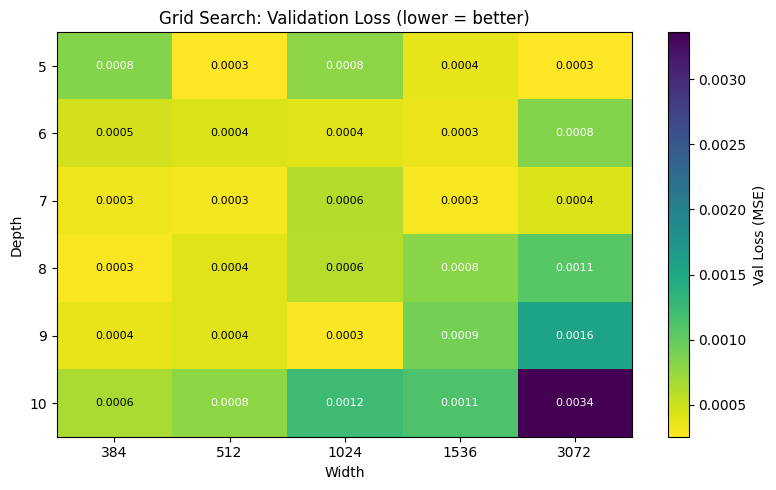

In [22]:
import numpy as np

heatmap = grid_df.pivot(index="depth", columns="width", values="best_val_loss")

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(heatmap.values, cmap="viridis_r", aspect="auto")

ax.set_xticks(range(len(GRID_WIDTHS)))
ax.set_xticklabels(GRID_WIDTHS)
ax.set_yticks(range(len(GRID_DEPTHS)))
ax.set_yticklabels(GRID_DEPTHS)
ax.set_xlabel("Width")
ax.set_ylabel("Depth")
ax.set_title("Grid Search: Validation Loss (lower = better)")

for i in range(len(GRID_DEPTHS)):
    for j in range(len(GRID_WIDTHS)):
        val = heatmap.values[i, j]
        ax.text(j, i, f"{val:.4f}", ha="center", va="center", fontsize=8,
                color="white" if val > heatmap.values.mean() else "black")

fig.colorbar(im, ax=ax, label="Val Loss (MSE)")
plt.tight_layout()
plt.show()

In [29]:
BEST_DEPTH = 5
BEST_WIDTH = 3072

LRS = [1e-3]
BATCH_SIZES = [256, 512, 1024]
WEIGHT_DECAYS = [1e-4, 1e-2]

print(f"HP sweep: {len(LRS)} LRs x {len(BATCH_SIZES)} batch sizes x {len(WEIGHT_DECAYS)} weight decays = {len(LRS)*len(BATCH_SIZES)*len(WEIGHT_DECAYS)} runs")
print(f"Architecture: depth={BEST_DEPTH}, width={BEST_WIDTH}")
print("Scheduler: ReduceLROnPlateau (always on)")

HP sweep: 1 LRs x 3 batch sizes x 2 weight decays = 6 runs
Architecture: depth=5, width=3072
Scheduler: ReduceLROnPlateau (always on)


In [30]:
from architectures.nn_build import build_mlp

hp_results = []

for bs in BATCH_SIZES:
    t_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=bs, shuffle=True)
    v_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=bs)

    for lr in LRS:
        for wd in WEIGHT_DECAYS:
            print(f"\n{'='*50}")
            print(f"BS={bs}, LR={lr}, WD={wd}")
            print(f"{'='*50}")

            torch.manual_seed(SEED)
            model = build_mlp(INPUT_DIM, OUTPUT_DIM, BEST_DEPTH, BEST_WIDTH, batch_norm=True).to(device)
            optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)
            criterion = nn.MSELoss()

            best_val = float("inf")
            best_state = None
            wait = 0

            for epoch in range(EPOCHS):
                model.train()
                train_loss = 0.0
                for xb, yb in t_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    pred = model(xb)
                    loss = criterion(pred, yb)
                    optimizer.zero_grad()
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()
                    train_loss += loss.item() * len(xb)
                train_loss /= len(t_loader.dataset)

                model.eval()
                val_loss = 0.0
                with torch.no_grad():
                    for xb, yb in v_loader:
                        xb, yb = xb.to(device), yb.to(device)
                        val_loss += criterion(model(xb), yb).item() * len(xb)
                val_loss /= len(v_loader.dataset)

                scheduler.step(val_loss)

                if val_loss < best_val:
                    best_val = val_loss
                    best_state = model.state_dict().copy()
                    wait = 0
                else:
                    wait += 1

                if (epoch + 1) % 10 == 0 or wait == 0:
                    print(f"  Epoch {epoch+1:3d} | Train: {train_loss:.6f} | Val: {val_loss:.6f} | Wait: {wait}")

                if wait >= PATIENCE:
                    print(f"  Early stop at epoch {epoch+1}")
                    break

            hp_results.append({"batch_size": bs, "lr": lr, "weight_decay": wd, "best_val_loss": best_val, "best_state": best_state})
            print(f"  Best Val Loss: {best_val:.6f}")


BS=256, LR=0.001, WD=0.0001
  Epoch   1 | Train: 0.257657 | Val: 0.107358 | Wait: 0
  Epoch   2 | Train: 0.036047 | Val: 0.003355 | Wait: 0
  Epoch   5 | Train: 0.015633 | Val: 0.002093 | Wait: 0
  Epoch   7 | Train: 0.008752 | Val: 0.000954 | Wait: 0
  Epoch  10 | Train: 0.003595 | Val: 0.000858 | Wait: 0
  Epoch  13 | Train: 0.002212 | Val: 0.000522 | Wait: 0
  Epoch  18 | Train: 0.001300 | Val: 0.000367 | Wait: 0
  Epoch  20 | Train: 0.001147 | Val: 0.000586 | Wait: 2
  Epoch  21 | Train: 0.001094 | Val: 0.000363 | Wait: 0
  Epoch  28 | Train: 0.000527 | Val: 0.000331 | Wait: 0
  Epoch  30 | Train: 0.000475 | Val: 0.000558 | Wait: 2
  Early stop at epoch 38
  Best Val Loss: 0.000331

BS=256, LR=0.001, WD=0.01
  Epoch   1 | Train: 0.259158 | Val: 0.036123 | Wait: 0
  Epoch   3 | Train: 0.023496 | Val: 0.009599 | Wait: 0
  Epoch   4 | Train: 0.016489 | Val: 0.003181 | Wait: 0
  Epoch   6 | Train: 0.009757 | Val: 0.000908 | Wait: 0
  Epoch  10 | Train: 0.002987 | Val: 0.000654 | Wait:

In [31]:
hp_df = pd.DataFrame([(r["lr"], r["batch_size"], r["weight_decay"], r["best_val_loss"])
                      for r in hp_results],
                     columns=["lr", "batch_size", "weight_decay", "best_val_loss"])
print(hp_df.sort_values("best_val_loss").to_string(index=False))

best_hp = hp_df.loc[hp_df["best_val_loss"].idxmin()]
print(f"\nBest: LR={best_hp['lr']}, Batch={int(best_hp['batch_size'])}, WD={best_hp['weight_decay']}, Val Loss={best_hp['best_val_loss']:.6f}")

   lr  batch_size  weight_decay  best_val_loss
0.001        1024        0.0001       0.000124
0.001         512        0.0100       0.000135
0.001         512        0.0001       0.000144
0.001        1024        0.0100       0.000163
0.001         256        0.0100       0.000299
0.001         256        0.0001       0.000331

Best: LR=0.001, Batch=1024, WD=0.0001, Val Loss=0.000124


/var/folders/t7/fntycq1j1qj6w3tkrbztnsbw0000gp/T/ipykernel_80724/1625186723.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


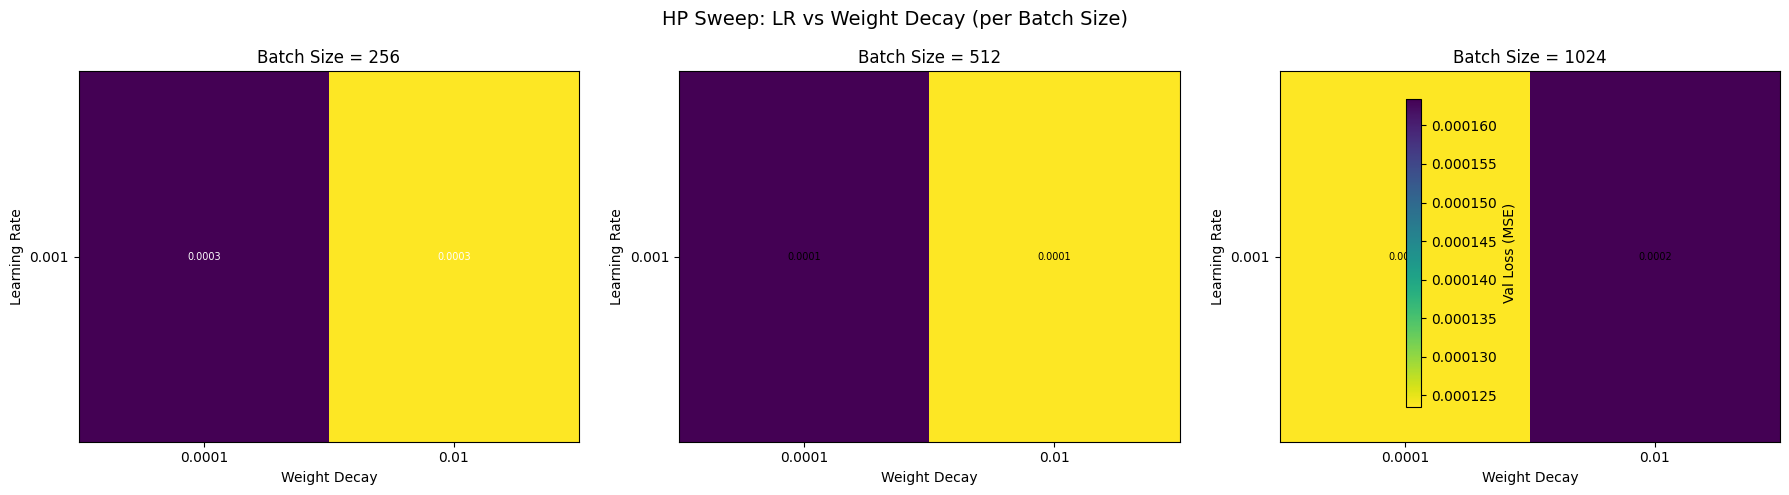

In [32]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, bs in enumerate(BATCH_SIZES):
    subset = hp_df[hp_df["batch_size"] == bs]
    hm = subset.pivot(index="lr", columns="weight_decay", values="best_val_loss")

    im = axes[i].imshow(hm.values, cmap="viridis_r", aspect="auto")
    axes[i].set_xticks(range(len(WEIGHT_DECAYS)))
    axes[i].set_xticklabels(WEIGHT_DECAYS)
    axes[i].set_yticks(range(len(LRS)))
    axes[i].set_yticklabels(LRS)
    axes[i].set_xlabel("Weight Decay")
    axes[i].set_ylabel("Learning Rate")
    axes[i].set_title(f"Batch Size = {bs}")

    for r in range(len(LRS)):
        for c in range(len(WEIGHT_DECAYS)):
            val = hm.values[r, c]
            axes[i].text(c, r, f"{val:.4f}", ha="center", va="center", fontsize=7,
                         color="white" if val > hp_df["best_val_loss"].mean() else "black")

fig.colorbar(im, ax=axes, label="Val Loss (MSE)", shrink=0.8)
fig.suptitle("HP Sweep: LR vs Weight Decay (per Batch Size)", fontsize=14)
plt.tight_layout()
plt.show()

In [33]:
best_idx = hp_df["best_val_loss"].idxmin()
best_state = hp_results[best_idx]["best_state"]

final_model = build_mlp(INPUT_DIM, OUTPUT_DIM, BEST_DEPTH, BEST_WIDTH, batch_norm=True).to(device)
final_model.load_state_dict(best_state)
final_model.eval()
print(f"Loaded best model: LR={hp_df.loc[best_idx, 'lr']}, BS={int(hp_df.loc[best_idx, 'batch_size'])}, WD={hp_df.loc[best_idx, 'weight_decay']}")
print(f"Val loss: {hp_df.loc[best_idx, 'best_val_loss']:.6f}")



Loaded best model: LR=0.001, BS=1024, WD=0.0001
Val loss: 0.000124


In [44]:
import numpy as np

X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

with torch.no_grad():
    preds_scaled = final_model(X_test_t).cpu().numpy()

preds = scaler_y.inverse_transform(preds_scaled).ravel()
y_true = y_test.values.ravel()

# Convert back to actual price: price_convertible = expm1(price_normalized)
preds_price = np.expm1(preds)
y_true_price = np.expm1(y_true)

mae = np.abs(preds_price - y_true_price).mean()
rmse = np.sqrt(((preds_price - y_true_price) ** 2).mean())

print(f"{'Metric':<10} {'Value':>12}")
print("-" * 24)
print(f"{'MAE':<10} {mae:>12.4f}")
print(f"{'RMSE':<10} {rmse:>12.4f}")

Metric            Value
------------------------
MAE              5.3781
RMSE            11.0421


/opt/homebrew/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but QuantileTransformer was fitted with feature names
  warnings.warn(


In [45]:
from sklearn.metrics import r2_score
import numpy as np

r2 = r2_score(y_true_price, preds_price)
median_ape = float(np.median(np.abs(preds_price - y_true_price) / np.abs(y_true_price)) * 100)

print(f"{'Metric':<14} {'Value':>12}")
print("-" * 28)
print(f"{'R²':<14} {r2:>12.6f}")
print(f"{'Median APE %':<14} {median_ape:>12.4f}")

Metric                Value
----------------------------
R²                 0.999904
Median APE %         0.7747


In [36]:
import matplotlib.pyplot as plt

test_features = df.loc[y_test.index]

analysis = pd.DataFrame({
    "price_true": y_true_price,
    "price_pred": preds_price,
    "price_err": np.abs(preds_price - y_true_price),
    "maturity_years": test_features["maturity_years"].values,
    "log_moneyness": test_features["log_moneyness"].values,
    "credit_spread": test_features["credit_spread"].values,
})

# Price regime buckets (dollar terms)
analysis["price_regime"] = pd.cut(analysis["price_true"],
    bins=[0, 200, 500, 1000, 2000, 6000],
    labels=["< $200", "$200-500", "$500-1k", "$1k-2k", "> $2k"])

# Maturity buckets
analysis["maturity"] = pd.cut(analysis["maturity_years"],
    bins=[0, 2, 5, 7, 10],
    labels=["< 2y", "2-5y", "5-7y", "> 7y"])

# Moneyness buckets
analysis["moneyness"] = pd.cut(analysis["log_moneyness"],
    bins=[-3, 0, 1, 2, 3, 5],
    labels=["OTM", "Near ATM", "Mild ITM", "ITM", "Deep ITM"])

# Credit risk buckets (spread in bps)
analysis["credit_risk"] = pd.cut(analysis["credit_spread"],
    bins=[0, 0.03, 0.06, 0.10, 0.15],
    labels=["Low (<300bp)", "Med (300-600bp)", "High (600-1000bp)", "Very High (>1000bp)"])

print("=== Price Error ($) by Price Regime ===")
regime_stats = analysis.groupby("price_regime", observed=True).agg(
    count=("price_err", "size"),
    MAE=("price_err", "mean"),
    RMSE=("price_err", lambda x: np.sqrt((x**2).mean())),
    R2=("price_true", lambda x: r2_score(
        analysis.loc[x.index, "price_true"], analysis.loc[x.index, "price_pred"]))
).reset_index()
print(regime_stats.to_string(index=False))

print("\n=== Price Error ($) by Maturity ===")
mat_stats = analysis.groupby("maturity", observed=True).agg(
    count=("price_err", "size"),
    MAE=("price_err", "mean"),
    RMSE=("price_err", lambda x: np.sqrt((x**2).mean())),
).reset_index()
print(mat_stats.to_string(index=False))

print("\n=== Price Error ($) by Moneyness ===")
mon_stats = analysis.groupby("moneyness", observed=True).agg(
    count=("price_err", "size"),
    MAE=("price_err", "mean"),
    RMSE=("price_err", lambda x: np.sqrt((x**2).mean())),
).reset_index()
print(mon_stats.to_string(index=False))

print("\n=== Price Error ($) by Credit Risk ===")
credit_stats = analysis.groupby("credit_risk", observed=True).agg(
    count=("price_err", "size"),
    MAE=("price_err", "mean"),
    RMSE=("price_err", lambda x: np.sqrt((x**2).mean())),
    R2=("price_true", lambda x: r2_score(
        analysis.loc[x.index, "price_true"], analysis.loc[x.index, "price_pred"]))
).reset_index()
print(credit_stats.to_string(index=False))

=== Price Error ($) by Price Regime ===
price_regime  count       MAE      RMSE       R2
      < $200 230957  0.530934  0.958667 0.999552
    $200-500  39378  3.528513  4.937426 0.996714
     $500-1k  28635  8.456157 10.399445 0.994820
      $1k-2k  28254 18.225577 20.610515 0.994832
       > $2k  41288 23.329377 26.347225 0.999298

=== Price Error ($) by Maturity ===
maturity  count      MAE      RMSE
    < 2y  23390 5.867118 11.684409
    2-5y  39957 5.719553 11.581992
    5-7y  24966 5.533818 11.305126
    > 7y  36014 5.467629 11.157665

=== Price Error ($) by Moneyness ===
moneyness  count       MAE      RMSE
      OTM 122479  0.506874  0.949607
 Near ATM  40999  1.687304  2.627161
 Mild ITM  40983  5.219275  6.992457
      ITM  40927 15.811062 18.446194
 Deep ITM  41081 23.338307 26.354808

=== Price Error ($) by Credit Risk ===
        credit_risk  count      MAE      RMSE       R2
       Low (<300bp)  35691 6.709391 12.887262 0.999866
    Med (300-600bp)  37148 5.795561 11.56097

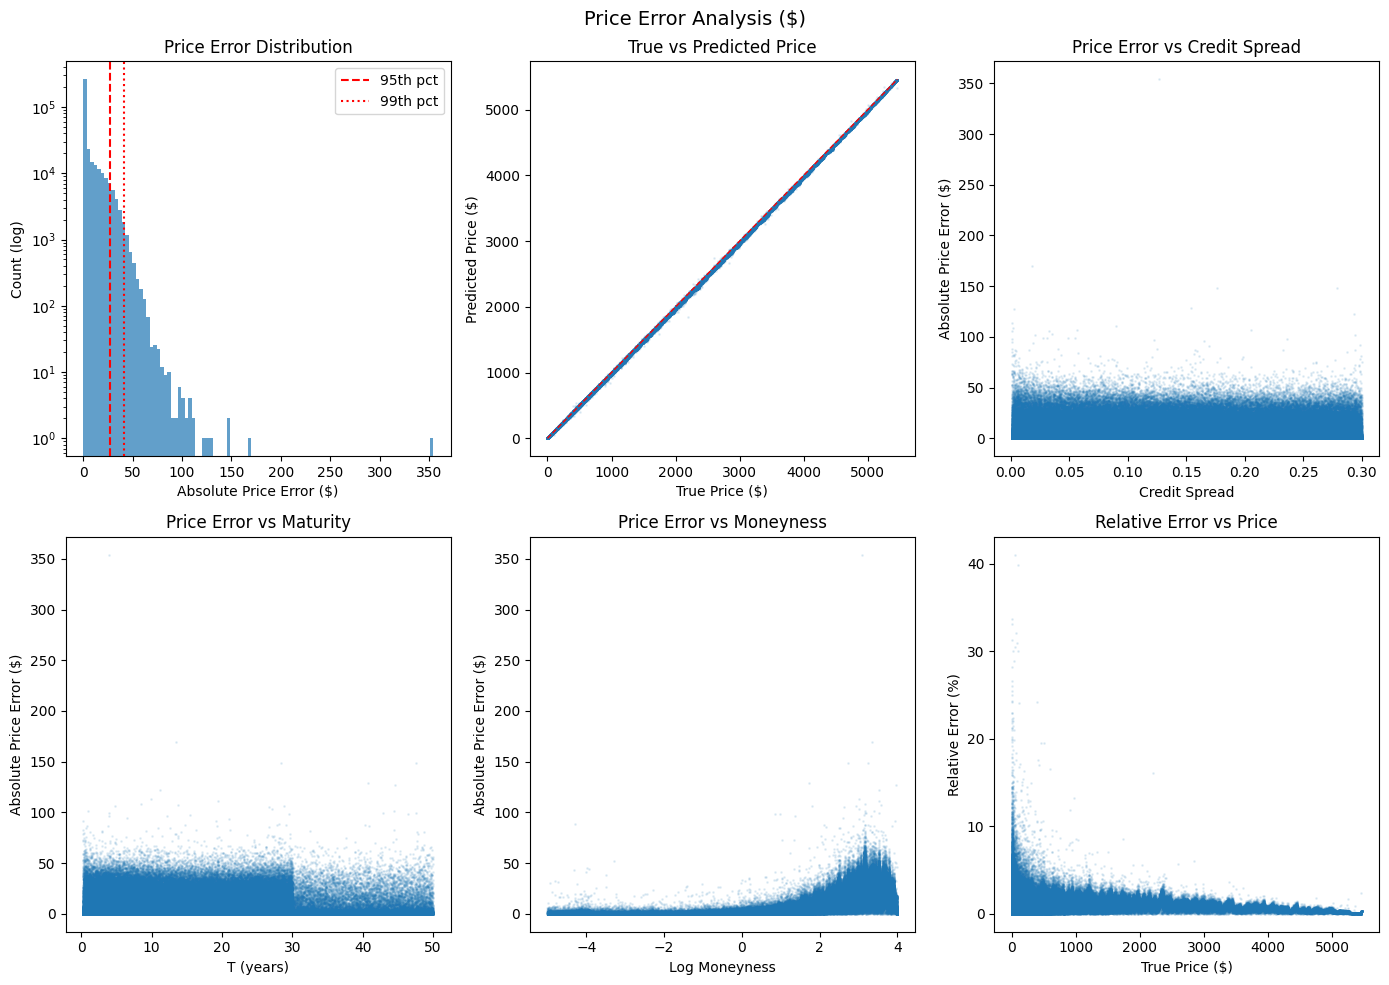

In [37]:
fig, axes = plt.subplots(2, 3, figsize=(14, 10))

# 1. Error distribution (log scale)
axes[0, 0].hist(analysis["price_err"], bins=100, edgecolor="none", alpha=0.7)
axes[0, 0].set_yscale("log")
axes[0, 0].set_xlabel("Absolute Price Error ($)")
axes[0, 0].set_ylabel("Count (log)")
axes[0, 0].set_title("Price Error Distribution")
axes[0, 0].axvline(analysis["price_err"].quantile(0.95), color="r", ls="--", label="95th pct")
axes[0, 0].axvline(analysis["price_err"].quantile(0.99), color="r", ls=":", label="99th pct")
axes[0, 0].legend()

# 2. True vs Predicted scatter
axes[0, 1].scatter(analysis["price_true"], analysis["price_pred"], s=1, alpha=0.1)
lims = [analysis["price_true"].min(), analysis["price_true"].max()]
axes[0, 1].plot(lims, lims, "r--", lw=1)
axes[0, 1].set_xlabel("True Price ($)")
axes[0, 1].set_ylabel("Predicted Price ($)")
axes[0, 1].set_title("True vs Predicted Price")

# 3. Error vs maturity
axes[1, 0].scatter(analysis["maturity_years"], analysis["price_err"], s=1, alpha=0.1)
axes[1, 0].set_xlabel("T (years)")
axes[1, 0].set_ylabel("Absolute Price Error ($)")
axes[1, 0].set_title("Price Error vs Maturity")

# 4. Error vs moneyness
axes[1, 1].scatter(analysis["log_moneyness"], analysis["price_err"], s=1, alpha=0.1)
axes[1, 1].set_xlabel("Log Moneyness")
axes[1, 1].set_ylabel("Absolute Price Error ($)")
axes[1, 1].set_title("Price Error vs Moneyness")

# 5. Error vs credit spread
axes[0, 2].scatter(analysis["credit_spread"], analysis["price_err"], s=1, alpha=0.1)
axes[0, 2].set_xlabel("Credit Spread")
axes[0, 2].set_ylabel("Absolute Price Error ($)")
axes[0, 2].set_title("Price Error vs Credit Spread")

# 6. Relative error (%) vs price
pct_err = analysis["price_err"] / analysis["price_true"] * 100
axes[1, 2].scatter(analysis["price_true"], pct_err, s=1, alpha=0.1)
axes[1, 2].set_xlabel("True Price ($)")
axes[1, 2].set_ylabel("Relative Error (%)")
axes[1, 2].set_title("Relative Error vs Price")

plt.suptitle("Price Error Analysis ($)", fontsize=14)
plt.tight_layout()
plt.show()


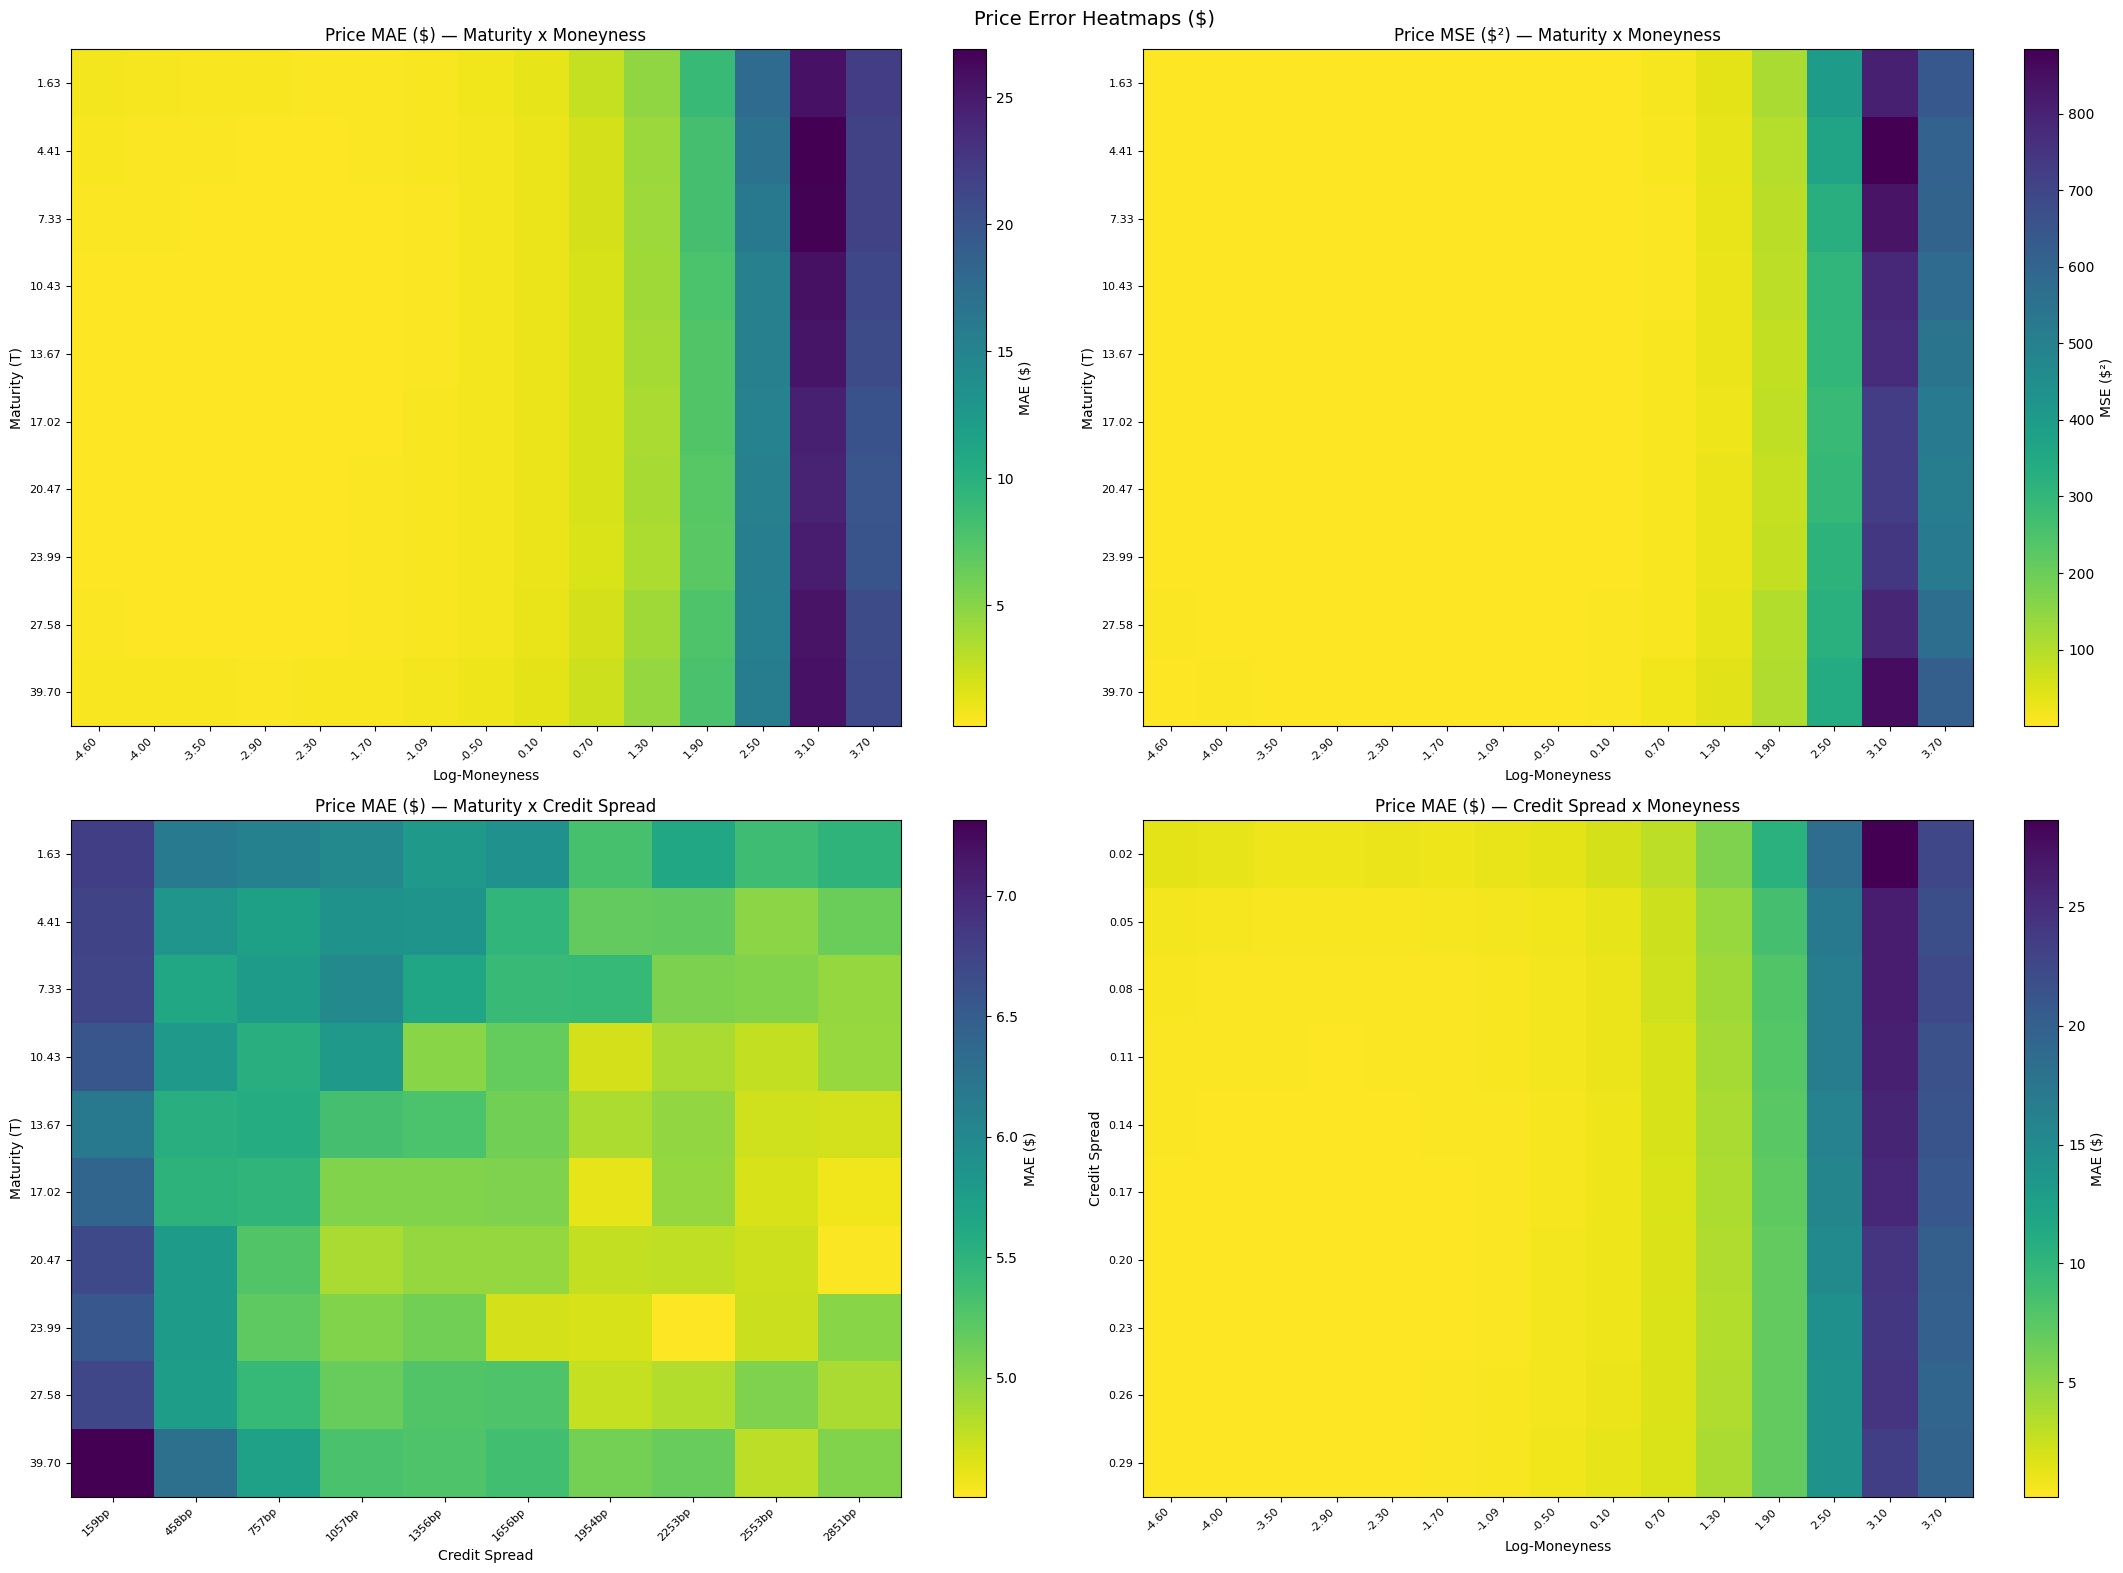

In [38]:
moneyness = analysis["log_moneyness"].values
maturity = analysis["maturity_years"].values
credit = analysis["credit_spread"].values
err_abs = analysis["price_err"].values
err_sq = err_abs ** 2

n_m, n_t, n_c = 15, 10, 10
m_edges = np.percentile(moneyness, np.linspace(0, 100, n_m + 1))
t_edges = np.percentile(maturity, np.linspace(0, 100, n_t + 1))
c_edges = np.percentile(credit, np.linspace(0, 100, n_c + 1))

m_idx = np.clip(np.digitize(moneyness, m_edges[1:-1]), 0, n_m - 1)
t_idx = np.clip(np.digitize(maturity, t_edges[1:-1]), 0, n_t - 1)
c_idx = np.clip(np.digitize(credit, c_edges[1:-1]), 0, n_c - 1)

def build_grid(row_idx, col_idx, n_row, n_col, vals):
    grid = np.full((n_row, n_col), np.nan)
    for ri in range(n_row):
        for ci in range(n_col):
            mask = (row_idx == ri) & (col_idx == ci)
            if mask.sum() > 0:
                grid[ri, ci] = vals[mask].mean()
    return grid

grid_mae_mm = build_grid(t_idx, m_idx, n_t, n_m, err_abs)
grid_mse_mm = build_grid(t_idx, m_idx, n_t, n_m, err_sq)
grid_mae_mc = build_grid(t_idx, c_idx, n_t, n_c, err_abs)
grid_mae_cm = build_grid(c_idx, m_idx, n_c, n_m, err_abs)

m_mids = 0.5 * (m_edges[:-1] + m_edges[1:])
t_mids = 0.5 * (t_edges[:-1] + t_edges[1:])
c_mids = 0.5 * (c_edges[:-1] + c_edges[1:])

fig, axes = plt.subplots(2, 2, figsize=(22, 16))

configs = [
    (axes[0, 0], grid_mae_mm, "Price MAE ($) — Maturity x Moneyness",
     m_mids, t_mids, "Log-Moneyness", "Maturity (T)", "MAE ($)", n_m, n_t, "moneyness"),
    (axes[0, 1], grid_mse_mm, "Price MSE ($²) — Maturity x Moneyness",
     m_mids, t_mids, "Log-Moneyness", "Maturity (T)", "MSE ($²)", n_m, n_t, "moneyness"),
    (axes[1, 0], grid_mae_mc, "Price MAE ($) — Maturity x Credit Spread",
     c_mids, t_mids, "Credit Spread", "Maturity (T)", "MAE ($)", n_c, n_t, "credit"),
    (axes[1, 1], grid_mae_cm, "Price MAE ($) — Credit Spread x Moneyness",
     m_mids, c_mids, "Log-Moneyness", "Credit Spread", "MAE ($)", n_m, n_c, "moneyness"),
]

for ax, grid, title, x_mids, y_mids, xlabel, ylabel, cbar_label, nx, ny, xtype in configs:
    im = ax.imshow(grid, aspect="auto", cmap="viridis_r")
    ax.set_xticks(range(nx))
    if xtype == "credit":
        ax.set_xticklabels([f"{int(v*10000)}bp" for v in x_mids], rotation=45, ha="right", fontsize=8)
    else:
        ax.set_xticklabels([f"{v:.2f}" for v in x_mids], rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(ny))
    ax.set_yticklabels([f"{v:.2f}" for v in y_mids], fontsize=8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label=cbar_label)

plt.suptitle("Price Error Heatmaps ($)", fontsize=14)
plt.tight_layout()
plt.show()


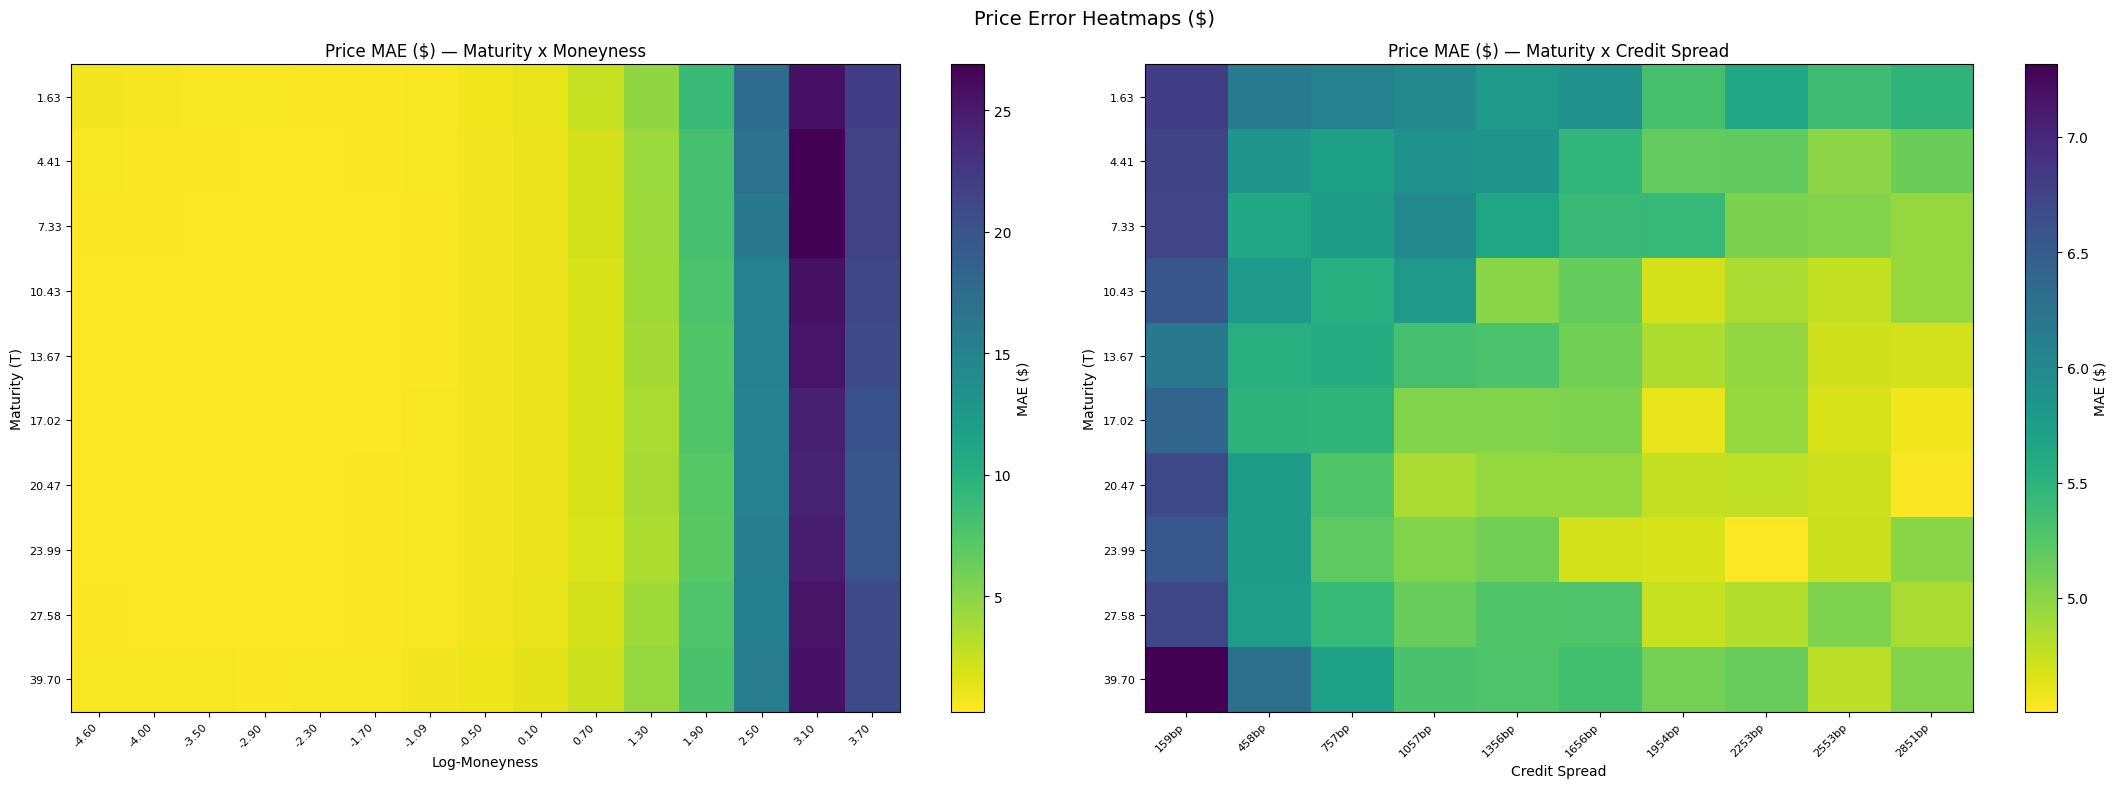

In [43]:
moneyness = analysis["log_moneyness"].values
maturity = analysis["maturity_years"].values
credit = analysis["credit_spread"].values
err_abs = analysis["price_err"].values

n_m, n_t, n_c = 15, 10, 10
m_edges = np.percentile(moneyness, np.linspace(0, 100, n_m + 1))
t_edges = np.percentile(maturity, np.linspace(0, 100, n_t + 1))
c_edges = np.percentile(credit, np.linspace(0, 100, n_c + 1))

m_idx = np.clip(np.digitize(moneyness, m_edges[1:-1]), 0, n_m - 1)
t_idx = np.clip(np.digitize(maturity, t_edges[1:-1]), 0, n_t - 1)
c_idx = np.clip(np.digitize(credit, c_edges[1:-1]), 0, n_c - 1)

def build_grid(row_idx, col_idx, n_row, n_col, vals):
    grid = np.full((n_row, n_col), np.nan)
    for ri in range(n_row):
        for ci in range(n_col):
            mask = (row_idx == ri) & (col_idx == ci)
            if mask.sum() > 0:
                grid[ri, ci] = vals[mask].mean()
    return grid

grid_mae_mm = build_grid(t_idx, m_idx, n_t, n_m, err_abs)
grid_mae_mc = build_grid(t_idx, c_idx, n_t, n_c, err_abs)

m_mids = 0.5 * (m_edges[:-1] + m_edges[1:])
t_mids = 0.5 * (t_edges[:-1] + t_edges[1:])
c_mids = 0.5 * (c_edges[:-1] + c_edges[1:])

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

configs = [
    (axes[0], grid_mae_mm, "Price MAE ($) — Maturity x Moneyness",
     m_mids, t_mids, "Log-Moneyness", "Maturity (T)", n_m, n_t, "moneyness"),
    (axes[1], grid_mae_mc, "Price MAE ($) — Maturity x Credit Spread",
     c_mids, t_mids, "Credit Spread", "Maturity (T)", n_c, n_t, "credit"),
]

for ax, grid, title, x_mids, y_mids, xlabel, ylabel, nx, ny, xtype in configs:
    im = ax.imshow(grid, aspect="auto", cmap="viridis_r")
    ax.set_xticks(range(nx))
    if xtype == "credit":
        ax.set_xticklabels([f"{int(v*10000)}bp" for v in x_mids], rotation=45, ha="right", fontsize=8)
    else:
        ax.set_xticklabels([f"{v:.2f}" for v in x_mids], rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(ny))
    ax.set_yticklabels([f"{v:.2f}" for v in y_mids], fontsize=8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label="MAE ($)")

plt.suptitle("Price Error Heatmaps ($)", fontsize=14)
plt.tight_layout()
plt.show()


## Clipped Test Set Evaluation

Re-evaluate on test subsets with extreme prediction errors removed:
- **Top 0.5% clipped**: remove samples above 99.5th percentile of absolute error
- **Symmetric 0.5% clipped**: remove samples below 0.25th and above 99.75th percentile of absolute error

In [39]:
err = analysis["price_err"]

# Top 0.5% clipped — remove worst 0.5% of errors
top_clip = err.quantile(0.995)
mask_top = err <= top_clip
a_top = analysis[mask_top]

mae_top = a_top["price_err"].mean()
rmse_top = np.sqrt((a_top["price_err"] ** 2).mean())
r2_top = r2_score(a_top["price_true"], a_top["price_pred"])

# Symmetric 0.5% clipped — remove bottom 0.25% and top 0.25% of errors
lo_clip = err.quantile(0.0025)
hi_clip = err.quantile(0.9975)
mask_sym = (err >= lo_clip) & (err <= hi_clip)
a_sym = analysis[mask_sym]

mae_sym = a_sym["price_err"].mean()
rmse_sym = np.sqrt((a_sym["price_err"] ** 2).mean())
r2_sym = r2_score(a_sym["price_true"], a_sym["price_pred"])

print(f"Full test set:        N={len(analysis):,}  MAE={analysis['price_err'].mean():.4f}  RMSE={np.sqrt((analysis['price_err']**2).mean()):.4f}  R²={r2_score(analysis['price_true'], analysis['price_pred']):.6f}")
print(f"Top 0.5% clipped:     N={len(a_top):,}  MAE={mae_top:.4f}  RMSE={rmse_top:.4f}  R²={r2_top:.6f}  (removed {len(analysis)-len(a_top):,} samples with err > {top_clip:.2f})")
print(f"Symmetric 0.5% clip:  N={len(a_sym):,}  MAE={mae_sym:.4f}  RMSE={rmse_sym:.4f}  R²={r2_sym:.6f}  (removed {len(analysis)-len(a_sym):,} samples)")

Full test set:        N=368,512  MAE=5.3781  RMSE=11.0421  R²=0.999904
Top 0.5% clipped:     N=366,669  MAE=5.1295  RMSE=10.3267  R²=0.999915  (removed 1,843 samples with err > 46.05)
Symmetric 0.5% clip:  N=366,668  MAE=5.2513  RMSE=10.6095  R²=0.999911  (removed 1,844 samples)


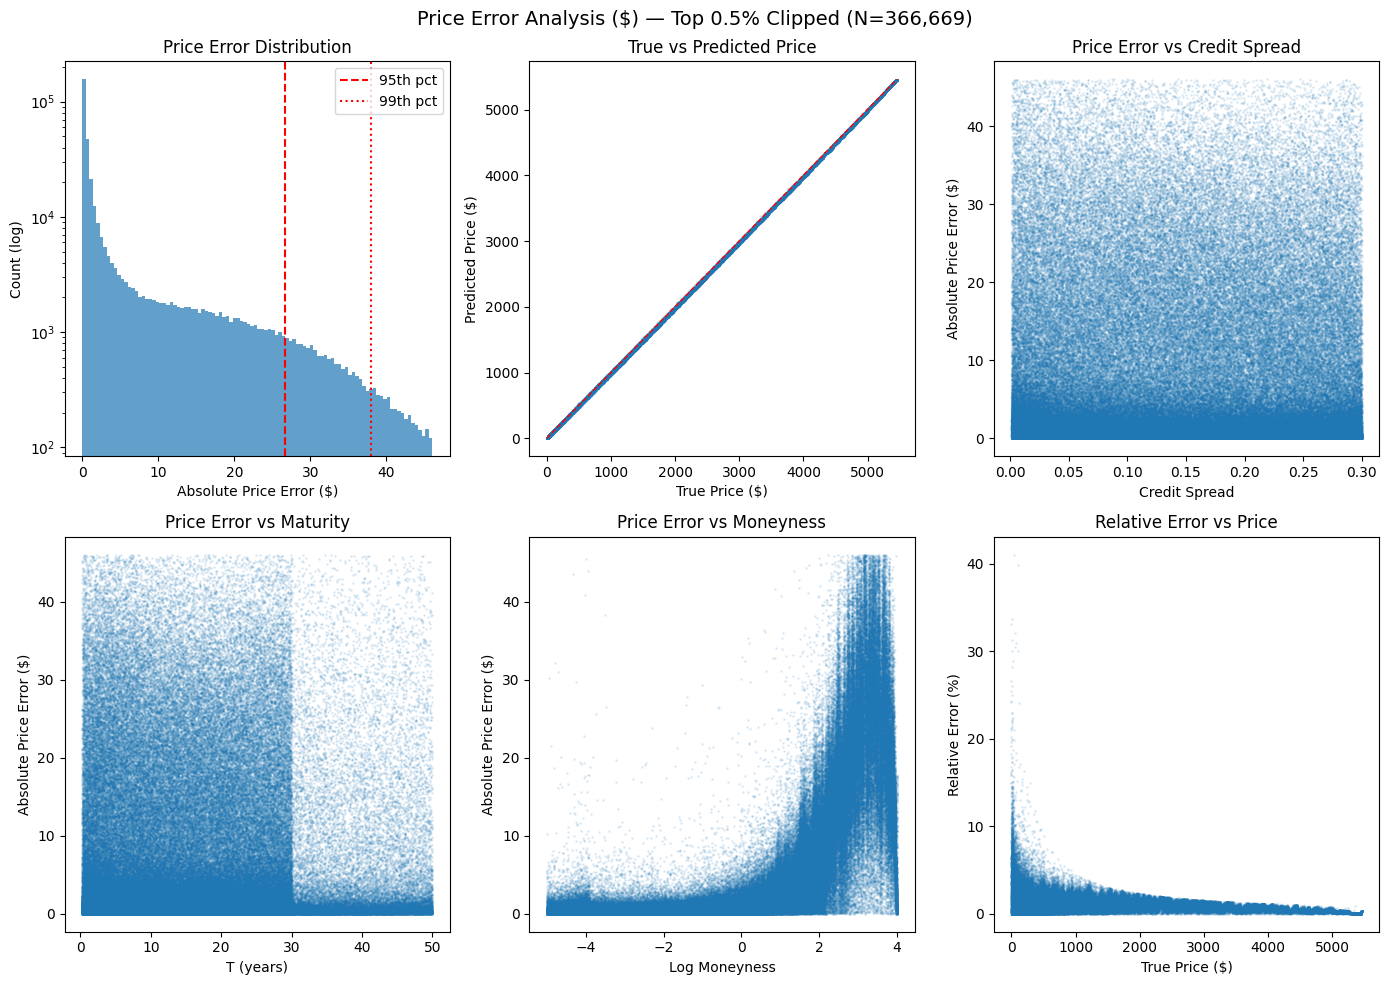

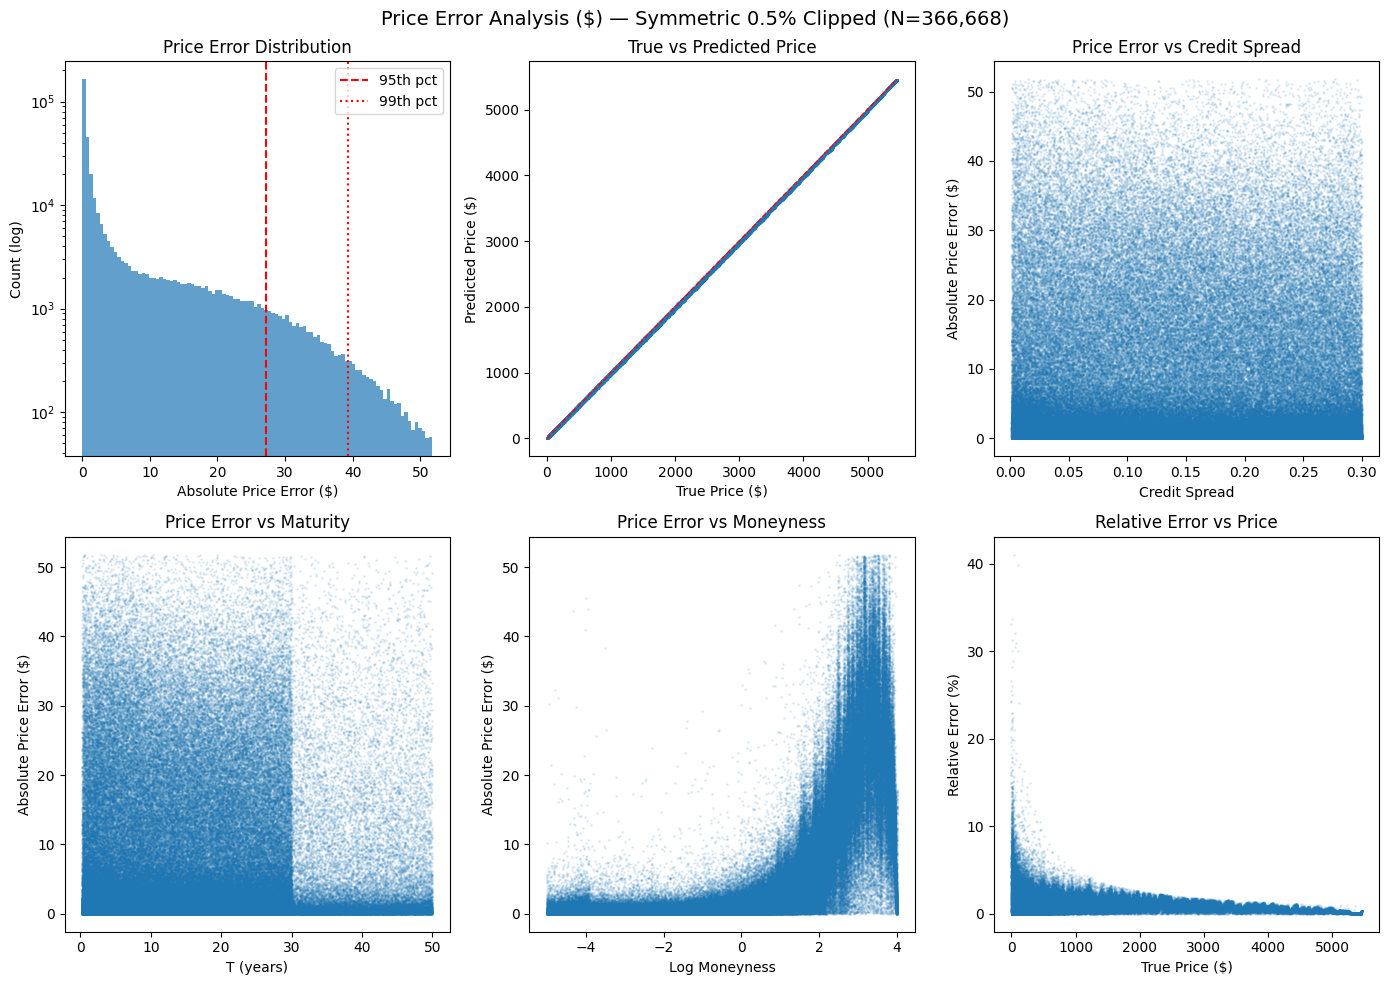

In [40]:
def plot_6panel(a, title_suffix):
    fig, axes = plt.subplots(2, 3, figsize=(14, 10))

    axes[0, 0].hist(a["price_err"], bins=100, edgecolor="none", alpha=0.7)
    axes[0, 0].set_yscale("log")
    axes[0, 0].set_xlabel("Absolute Price Error ($)")
    axes[0, 0].set_ylabel("Count (log)")
    axes[0, 0].set_title("Price Error Distribution")
    axes[0, 0].axvline(a["price_err"].quantile(0.95), color="r", ls="--", label="95th pct")
    axes[0, 0].axvline(a["price_err"].quantile(0.99), color="r", ls=":", label="99th pct")
    axes[0, 0].legend()

    axes[0, 1].scatter(a["price_true"], a["price_pred"], s=1, alpha=0.1)
    lims = [a["price_true"].min(), a["price_true"].max()]
    axes[0, 1].plot(lims, lims, "r--", lw=1)
    axes[0, 1].set_xlabel("True Price ($)")
    axes[0, 1].set_ylabel("Predicted Price ($)")
    axes[0, 1].set_title("True vs Predicted Price")

    axes[1, 0].scatter(a["maturity_years"], a["price_err"], s=1, alpha=0.1)
    axes[1, 0].set_xlabel("T (years)")
    axes[1, 0].set_ylabel("Absolute Price Error ($)")
    axes[1, 0].set_title("Price Error vs Maturity")

    axes[1, 1].scatter(a["log_moneyness"], a["price_err"], s=1, alpha=0.1)
    axes[1, 1].set_xlabel("Log Moneyness")
    axes[1, 1].set_ylabel("Absolute Price Error ($)")
    axes[1, 1].set_title("Price Error vs Moneyness")

    axes[0, 2].scatter(a["credit_spread"], a["price_err"], s=1, alpha=0.1)
    axes[0, 2].set_xlabel("Credit Spread")
    axes[0, 2].set_ylabel("Absolute Price Error ($)")
    axes[0, 2].set_title("Price Error vs Credit Spread")

    pct_err = a["price_err"] / a["price_true"] * 100
    axes[1, 2].scatter(a["price_true"], pct_err, s=1, alpha=0.1)
    axes[1, 2].set_xlabel("True Price ($)")
    axes[1, 2].set_ylabel("Relative Error (%)")
    axes[1, 2].set_title("Relative Error vs Price")

    plt.suptitle(f"Price Error Analysis ($) — {title_suffix}", fontsize=14)
    plt.tight_layout()
    plt.show()

plot_6panel(a_top, f"Top 0.5% Clipped (N={len(a_top):,})")
plot_6panel(a_sym, f"Symmetric 0.5% Clipped (N={len(a_sym):,})")

In [41]:
import os
import pickle

save_dir = "../models"
os.makedirs(save_dir, exist_ok=True)

torch.save({
    "model_state_dict": final_model.state_dict(),
    "input_dim": INPUT_DIM,
    "output_dim": OUTPUT_DIM,
    "depth": BEST_DEPTH,
    "width": BEST_WIDTH,
}, os.path.join(save_dir, "baseline_fnn.pt"))

with open(os.path.join(save_dir, "scaler_X.pkl"), "wb") as f:
    pickle.dump(scaler_X, f)
with open(os.path.join(save_dir, "scaler_y.pkl"), "wb") as f:
    pickle.dump(scaler_y, f)

print(f"Model saved to {save_dir}/baseline_fnn.pt")
print(f"Scalers saved to {save_dir}/scaler_X.pkl, scaler_y.pkl")

Model saved to ../models/baseline_fnn.pt
Scalers saved to ../models/scaler_X.pkl, scaler_y.pkl
